# VADER Evaluation & Validation

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from scipy import stats
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data if not already present
import nltk
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    print("Downloading NLTK VADER lexicon...")
    nltk.download('vader_lexicon', quiet=True)
    print("NLTK VADER lexicon downloaded.")

# Load the dataset
df = pd.read_csv('/content/egovph.csv')

print("Data loaded successfully.")

Data loaded successfully.


This section evaluates the quality and reliability of VADER sentiment analysis on text data. Since this is unsupervised learning, we use internal validation metrics to assess sentiment consistency and distribution.

In [17]:
# Initialize VADER
sia = SentimentIntensityAnalyzer()

# Ensure sentiment scores exist
if 'sentiment_score' not in df.columns:
    def get_sentiment_scores(text):
        if pd.isna(text) or str(text).strip() == '':
            return 0.0
        return sia.polarity_scores(str(text))['compound']

    df['sentiment_score'] = df['translated'].apply(get_sentiment_scores)
    df['sentiment'] = df['sentiment_score'].apply(
        lambda x: 'Positive' if x >= 0.05 else ('Negative' if x <= -0.05 else 'Neutral')
    )

print("VADER sentiment scores calculated.")

VADER sentiment scores calculated.


## 📊 Sentiment Distribution Quality Metrics

Distribution Entropy: 0.742 (Measures balance between sentiment classes. Higher = more balanced distribution)
Polarity Balance: 0.350 (Balance between positive and negative reviews. 1 = perfectly balanced)
Neutral Ratio: 17.3% (Percentage of neutral reviews. Very high neutral ratio may indicate issues)
Avg Sentiment Strength: 0.437 (Average absolute sentiment score. Higher = more confident classifications)

Sentiment Class Balance:


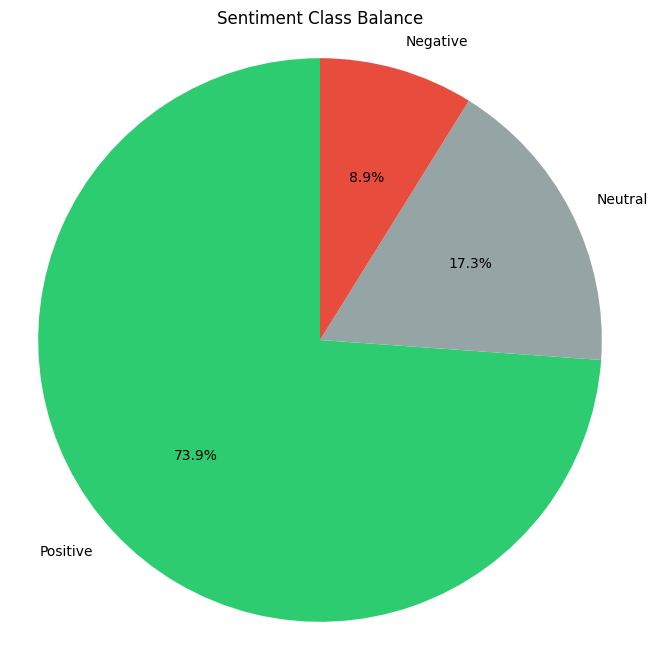


Sentiment Score Distribution:


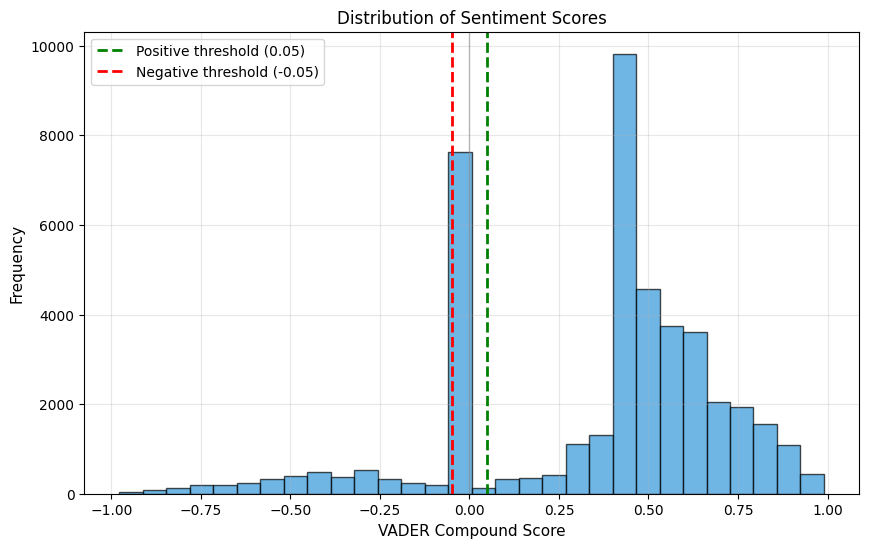

In [18]:
sentiment_counts = df['sentiment'].value_counts()
entropy = stats.entropy(sentiment_counts.values / len(df))
print(f"Distribution Entropy: {entropy:.3f} (Measures balance between sentiment classes. Higher = more balanced distribution)")

pos_ratio = (df['sentiment'] == 'Positive').mean()
neg_ratio = (df['sentiment'] == 'Negative').mean()
balance_score = 1 - abs(pos_ratio - neg_ratio)
print(f"Polarity Balance: {balance_score:.3f} (Balance between positive and negative reviews. 1 = perfectly balanced)")

neutral_ratio = (df['sentiment'] == 'Neutral').mean()
print(f"Neutral Ratio: {neutral_ratio:.1%} (Percentage of neutral reviews. Very high neutral ratio may indicate issues)")

avg_magnitude = df['sentiment_score'].abs().mean()
print(f"Avg Sentiment Strength: {avg_magnitude:.3f} (Average absolute sentiment score. Higher = more confident classifications)")

# Sentiment Class Balance (Pie Chart)
print("\nSentiment Class Balance:")
sentiment_df = pd.DataFrame({
    'Sentiment': ['Positive', 'Neutral', 'Negative'],
    'Count': [
        (df['sentiment'] == 'Positive').sum(),
        (df['sentiment'] == 'Neutral').sum(),
        (df['sentiment'] == 'Negative').sum()
    ]
})

fig1, ax1 = plt.subplots(figsize=(8, 8))
colors = ['#2ecc71', '#95a5a6', '#e74c3c']
ax1.pie(sentiment_df['Count'], labels=sentiment_df['Sentiment'], autopct='%1.1f%%', colors=colors, startangle=90)
ax1.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
ax1.set_title('Sentiment Class Balance')
plt.show()

# Sentiment Score Distribution (Histogram)
print("\nSentiment Score Distribution:")
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.hist(df['sentiment_score'], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
ax2.axvline(x=0.05, color='green', linestyle='--', linewidth=2, label='Positive threshold (0.05)')
ax2.axvline(x=-0.05, color='red', linestyle='--', linewidth=2, label='Negative threshold (-0.05)')
ax2.axvline(x=0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
ax2.set_xlabel('VADER Compound Score', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Distribution of Sentiment Scores', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.show()

## 🎯 Clustering Validation Metrics
These metrics validate if reviews naturally cluster by sentiment without supervision.

Silhouette Score: 0.150 (Good > 0.3: Poor. Measures how similar reviews are to their own sentiment cluster vs other clusters. Higher = better separation)
Davies-Bouldin: 1.544 (Good < 1.5: Poor. Average similarity between clusters. Lower = more distinct sentiment groups)
Calinski-Harabasz: 4042 (Ratio of between-cluster to within-cluster variance. Higher = better defined clusters)

VADER vs. Unsupervised Clustering Agreement:
VADER-Clustering Agreement: 73.9% (Percentage where VADER labels match unsupervised clustering)

Agreement Matrix:
Cluster_Group    Positive
VADER_Sentiment          
Negative             3890
Neutral              7583
Positive            32434

Cluster Separation Visualization (PCA):


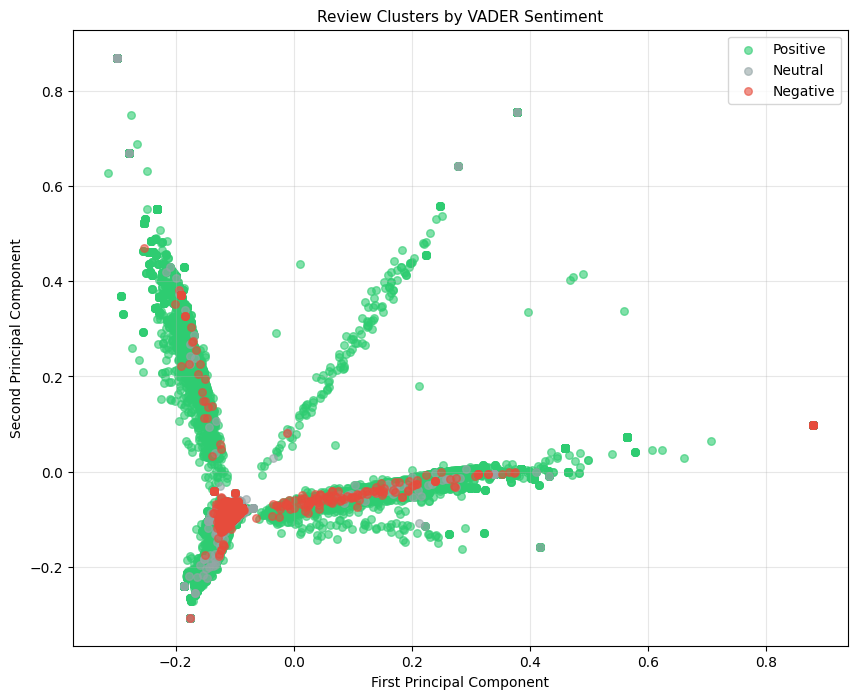

In [19]:
vectorizer = TfidfVectorizer(max_features=500, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df['translated'].fillna(''))

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(tfidf_matrix)

sil_score = silhouette_score(tfidf_matrix, cluster_labels, metric='cosine')
print(f"Silhouette Score: {sil_score:.3f} (Good > 0.3: {'Good' if sil_score > 0.3 else 'Poor'}. Measures how similar reviews are to their own sentiment cluster vs other clusters. Higher = better separation)")

db_score = davies_bouldin_score(tfidf_matrix.toarray(), cluster_labels)
print(f"Davies-Bouldin: {db_score:.3f} (Good < 1.5: {'Good' if db_score < 1.5 else 'Poor'}. Average similarity between clusters. Lower = more distinct sentiment groups)")

ch_score = calinski_harabasz_score(tfidf_matrix.toarray(), cluster_labels)
print(f"Calinski-Harabasz: {ch_score:.0f} (Ratio of between-cluster to within-cluster variance. Higher = better defined clusters)")

# Compare VADER labels with K-means clusters
print("\nVADER vs. Unsupervised Clustering Agreement:")

cluster_sentiment_map = {}
for cluster in range(3):
    cluster_reviews = df.iloc[cluster_labels == cluster]
    dominant_sentiment = cluster_reviews['sentiment'].mode()[0] if len(cluster_reviews) > 0 else 'Neutral'
    cluster_sentiment_map[cluster] = dominant_sentiment

predicted_sentiments = [cluster_sentiment_map[label] for label in cluster_labels]
agreement = (df['sentiment'] == predicted_sentiments).mean()
print(f"VADER-Clustering Agreement: {agreement:.1%} (Percentage where VADER labels match unsupervised clustering)")

print("\nAgreement Matrix:")
comparison_df = pd.DataFrame({
    'VADER_Sentiment': df['sentiment'],
    'Cluster_Group': predicted_sentiments
})
agreement_matrix = pd.crosstab(comparison_df['VADER_Sentiment'], comparison_df['Cluster_Group'])
print(agreement_matrix)

# Cluster Separation Visualization
print("\nCluster Separation Visualization (PCA):")
pca = PCA(n_components=2)
tfidf_pca = pca.fit_transform(tfidf_matrix.toarray())

fig3, ax3 = plt.subplots(figsize=(10, 8))
colors = {'Positive': '#2ecc71', 'Neutral': '#95a5a6', 'Negative': '#e74c3c'}
sentiment_order = ['Positive', 'Neutral', 'Negative']

for sentiment in sentiment_order:
    mask = df['sentiment'] == sentiment
    ax3.scatter(tfidf_pca[mask, 0], tfidf_pca[mask, 1],
              c=colors[sentiment], label=sentiment, alpha=0.6, s=30)

ax3.set_xlabel('First Principal Component', fontsize=10)
ax3.set_ylabel('Second Principal Component', fontsize=10)
ax3.set_title('Review Clusters by VADER Sentiment', fontsize=11)
ax3.legend()
ax3.grid(True, alpha=0.3)
plt.show()

## 📏 Consistency Analysis
Evaluating if VADER performs consistently across different review lengths.

In [20]:
df['review_length'] = df['translated'].str.len()
df['length_category'] = pd.cut(df['review_length'],
                               bins=[0, 50, 200, 500, float('inf')],
                               labels=['Very Short (<50)', 'Short (50-200)', 'Medium (200-500)', 'Long (500+)'])

length_sentiment = df.groupby('length_category').agg({
    'sentiment_score': ['mean', 'std', 'count']
}).round(3)
length_sentiment.columns = ['Mean Sentiment', 'Std Dev', 'Count']

print("\nAverage Sentiment Strength by Review Length Category:")
print(length_sentiment)

length_groups = [group['sentiment_score'].values for name, group in df.groupby('length_category')]

p_value = None # Initialize p_value
if len(length_groups) >= 2:
    f_stat, p_value = stats.f_oneway(*length_groups)
    print(f"\nANOVA Test: F-statistic = {f_stat:.3f}, p-value = {p_value:.4f}")
    if p_value < 0.05:
        print("⚠️ Significant differences in sentiment scores across review lengths detected")
    else:
        print("✅ Sentiment scores are consistent across review lengths")
else:
    print("Not enough length categories to perform ANOVA test.")


Average Sentiment Strength by Review Length Category:
                  Mean Sentiment  Std Dev  Count
length_category                                 
Very Short (<50)           0.386    0.280  32255
Short (50-200)             0.298    0.473   9727
Medium (200-500)           0.279    0.620   1919
Long (500+)               -0.099    0.761      6

ANOVA Test: F-statistic = 196.455, p-value = 0.0000
⚠️ Significant differences in sentiment scores across review lengths detected


## 🔍 VADER Component Analysis
Breakdown of VADER's four sentiment components.


Average VADER Component Scores:
  Component  Average Score
0  Positive       0.483072
1  Negative       0.029601
2   Neutral       0.487213

Component Correlation Matrix:


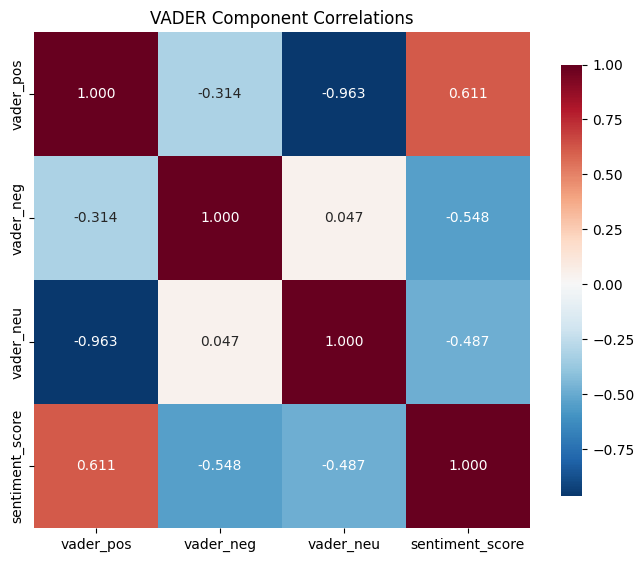

In [21]:
# Calculate all VADER components
pos_scores = []
neg_scores = []
neu_scores = []
compound_scores = []

for text in df['translated'].fillna(''):
    scores = sia.polarity_scores(str(text))
    pos_scores.append(scores['pos'])
    neg_scores.append(scores['neg'])
    neu_scores.append(scores['neu'])
    compound_scores.append(scores['compound'])

df['vader_pos'] = pos_scores
df['vader_neg'] = neg_scores
df['vader_neu'] = neu_scores

component_means = pd.DataFrame({
    'Component': ['Positive', 'Negative', 'Neutral'],
    'Average Score': [df['vader_pos'].mean(), df['vader_neg'].mean(), df['vader_neu'].mean()]
})

print("\nAverage VADER Component Scores:")
print(component_means)

# Component Correlation Matrix
print("\nComponent Correlation Matrix:")
corr_matrix = df[['vader_pos', 'vader_neg', 'vader_neu', 'sentiment_score']].corr()

fig4, ax4 = plt.subplots(figsize=(8, 7))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
            fmt='.3f', square=True, ax=ax4, cbar_kws={'shrink': 0.8})
ax4.set_title('VADER Component Correlations', fontsize=12)
plt.show()

## 🎯 VADER Reliability Assessment


Overall VADER Reliability Score: 65/100
Status: Needs Improvement

Component Scores:
              Metric Score
Distribution Balance 10/20
  Clustering Quality 15/30
  Sentiment Strength 17/20
  Length Consistency  8/15
   Low Neutral Ratio 15/15

Recommendations:
• Poor clustering separation - Reviews may need better preprocessing or additional context
• Length bias detected - VADER performs differently on short vs long reviews


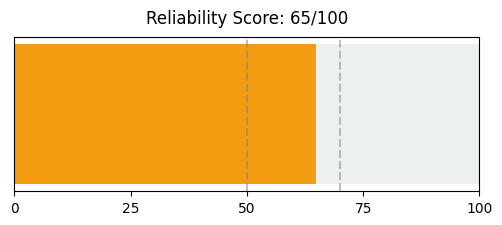

In [22]:
# Calculate overall reliability score (0-100)
reliability_score = 0

# Factor 1: Distribution balance (20 points)
entropy_score = min(entropy / 1.5, 1.0) * 20
reliability_score += entropy_score

# Factor 2: Clustering quality (30 points)
if sil_score > 0.3:
    clustering_score = min((sil_score - 0.3) / 0.4 * 30, 30)
else:
    clustering_score = max(sil_score / 0.3 * 30, 0)
reliability_score += clustering_score

# Factor 3: Sentiment strength (20 points)
strength_score = min(avg_magnitude / 0.5 * 20, 20)
reliability_score += strength_score

# Factor 4: Length consistency (15 points)
if p_value is not None and p_value > 0.05:
    consistency_score = 15
else:
    consistency_score = 7.5
reliability_score += consistency_score

# Factor 5: Low neutral ratio (15 points)
if neutral_ratio < 0.3:
    neutral_score = 15
elif neutral_ratio < 0.5:
    neutral_score = 10
else:
    neutral_score = 5
reliability_score += neutral_score

reliability_score = min(reliability_score, 100)

print(f"\nOverall VADER Reliability Score: {reliability_score:.0f}/100")
print(f"Status: {'Good' if reliability_score >= 70 else 'Needs Improvement' if reliability_score >= 50 else 'Poor'}")

# Component Scores
print("\nComponent Scores:")
component_scores = pd.DataFrame({
    'Metric': ['Distribution Balance', 'Clustering Quality', 'Sentiment Strength', 'Length Consistency', 'Low Neutral Ratio'],
    'Score': [f"{entropy_score:.0f}/20", f"{clustering_score:.0f}/30", f"{strength_score:.0f}/20", f"{consistency_score:.0f}/15", f"{neutral_score:.0f}/15"]
})
print(component_scores.to_string(index=False))

# Recommendations
print("\nRecommendations:")

recommendations = []
if neutral_ratio > 0.5:
    recommendations.append("• High neutral ratio detected - Consider using aspect-based sentiment analysis or reviewing ambiguous cases")
if sil_score < 0.3:
    recommendations.append("• Poor clustering separation - Reviews may need better preprocessing or additional context")
if avg_magnitude < 0.3:
    recommendations.append("• Low sentiment strength - Reviews may be too neutral or brief for clear classification")
if p_value is not None and p_value < 0.05:
    recommendations.append("• Length bias detected - VADER performs differently on short vs long reviews")

if recommendations:
    for rec in recommendations:
        print(rec)
else:
    print("✅ VADER is performing well on your review data! The sentiment analysis appears reliable.")

# Gauge chart
fig_gauge, ax_gauge = plt.subplots(figsize=(6, 2))

# Create horizontal bar gauge
ax_gauge.barh([0], [100], left=0, color='#ecf0f1', height=0.3)
if reliability_score < 50:
    color = '#e74c3c'
elif reliability_score < 70:
    color = '#f39c12'
else:
    color = '#2ecc71'
ax_gauge.barh([0], [reliability_score], left=0, color=color, height=0.3)

ax_gauge.set_xlim(0, 100)
ax_gauge.set_yticks([])
ax_gauge.set_xticks([0, 25, 50, 75, 100])
ax_gauge.set_xticklabels(['0', '25', '50', '75', '100'])
ax_gauge.set_title(f'Reliability Score: {reliability_score:.0f}/100', fontsize=12, pad=10)
ax_gauge.axvline(x=50, color='gray', linestyle='--', alpha=0.5)
ax_gauge.axvline(x=70, color='gray', linestyle='--', alpha=0.5)
plt.show()

## ⚠️ Ambiguous Cases Analysis
Reviews where VADER shows uncertainty or potential misclassification.

In [23]:
# Identify uncertain cases
df['uncertainty'] = 1 - (df['vader_pos'] + df['vader_neg'])  # High uncertainty when both pos and neg are low
df['sentiment_strength_abs'] = df['sentiment_score'].abs()

ambiguous_df = df[
    (df['sentiment_strength_abs'] < 0.2) |  # Weak sentiment
    (df['uncertainty'] > 0.7)  # High uncertainty
].head(10)

if len(ambiguous_df) > 0:
    print("\nPotentially Misclassified or Unclear Reviews:")
    for idx, row in ambiguous_df.iterrows():
        print(f"💬 {row['translated'][:150]}... (Sentiment: {row['sentiment']}, Score: {row['sentiment_score']:.3f})")
else:
    print("No highly ambiguous cases detected. All reviews have clear sentiment signals.")


Potentially Misclassified or Unclear Reviews:
💬 absolutely great...... (Sentiment: Neutral, Score: 0.000)
💬 trash... (Sentiment: Neutral, Score: 0.000)
💬 this app is not working as of the moment i dont know why? i cannot access the website i want to check such as my sss pagibig and philhealth including ... (Sentiment: Negative, Score: -0.316)
💬 very... (Sentiment: Neutral, Score: 0.000)
💬 very nice because you see your id and national... (Sentiment: Positive, Score: 0.475)
💬 i got it... (Sentiment: Neutral, Score: 0.000)
💬 as of the app i have experienced a very slow loading screen time and even my internet is stable its still functioning very slowly. clicking the qr doe... (Sentiment: Positive, Score: 0.886)
💬 I thought I couldn't verify my gcash because my national ID hasn't arrived for a long time. It's been a while since those who work in the government a... (Sentiment: Positive, Score: 0.570)
💬 it's nice to see my national id again... (Sentiment: Positive, Score: 0.421)
💬 this ap